In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

/var/folders/bv/69kbxjqs7j39ws_sdsj8g_8w0000gn/T/ipykernel_27806/1606832313.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book2.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)

In [13]:
docs[0]

Document(metadata={'producer': 'Acrobat Distiller 6.0 (Windows)', 'creator': 'Adobe Acrobat 6.0', 'creationdate': '2006-10-18T12:52:36+08:00', 'author': 'Christopher M. Bishop', 'moddate': '2008-02-08T16:41:33+01:00', 'title': 'Pattern Recognition and Machine Learning', 'source': './documents/book1.pdf', 'total_pages': 758, 'page': 0, 'page_label': 'i'}, page_content='')

In [3]:
len(docs)

2123

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [14]:
chunks[0]

Document(metadata={'producer': 'Acrobat Distiller 6.0 (Windows)', 'creator': 'Adobe Acrobat 6.0', 'creationdate': '2006-10-18T12:52:36+08:00', 'author': 'Christopher M. Bishop', 'moddate': '2008-02-08T16:41:33+01:00', 'title': 'Pattern Recognition and Machine Learning', 'source': './documents/book1.pdf', 'total_pages': 758, 'page': 1, 'page_label': 'ii'}, page_content='Information Science and Statistics\nSeries Editors:\nM. Jordan\nJ. Kleinberg\nB. Scho¨lkopf')

In [5]:
len(chunks)

6393

In [6]:
# Index(Fresh collection each run )
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [7]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [8]:
# 4) LLM + prompt
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [9]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [10]:
def retrieve(state: State):
    q = state['question']
    return {'docs': retriever.invoke(q)}

In [17]:
list(retriever.invoke("what is machine learning")[0])

[('id', '0a35c95f-1d98-4970-a3d3-04c068455a42'),
 ('metadata',
  {'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)',
   'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)',
   'creationdate': '2017-03-10T21:55:34+00:00',
   'author': 'Aurélien Géron',
   'moddate': '2017-07-29T21:43:02+08:00',
   'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow',
   'trapped': '/False',
   'source': './documents/book3.pdf',
   'total_pages': 564,
   'page': 50,
   'page_label': '29'}),
 ('page_content',
  '• Machine Learning is about making machines get better at some task by learning\nfrom data, instead of having to explicitly code rules.\n• There are man\ny different types of ML systems: supervised or not, batch or online,\ninstance-based or model-based, and so on.\n• In a ML project you gather data in a training set, and you feed the training set to\na learning algorithm. If the algorithm is model-based it tunes some parameters to

In [18]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generate(state: State):
    context = "\n\n".join(d.page_content for d in state['docs'])
    out = (prompt | llm).invoke({"question": state['question'], "context": context})
    return {"answer": out.content}

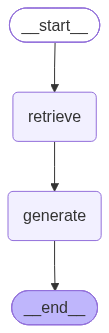

In [19]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [ ]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

The context does not provide a definition or explanation of a transformer in deep learning. Therefore, I don't know.


In [ ]:

res = app.invoke({"question": "WHat is deep learning.", "docs": [], "answer": ""})
print(res["answer"])


Deep learning is an approach to artificial intelligence (AI) that is a type of machine learning. It allows computer systems to improve with experience and data. Deep learning involves the study of models that either involve a greater amount of composition of learned functions or learned concepts than traditional machine learning. It emphasizes the ability to train deeper neural networks, which has been made possible through advancements in training strategies and the availability of large datasets.
4


In [25]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

relevant,andbecausediﬀerentpeoplechoosediﬀerentsetsofsmallestelements
fromwhichtoconstructtheirgraphs,thereisnosinglecorrectvalueforthe
depthofanarchitecture,justasthereisnosinglecorrectvalueforthelengthof
acomputerprogram. Noristhereaconsensusabouthowmuchdepthamodel
requirestoqualifyas“deep.”However,deeplearningcansafelyberegardedasthe
studyofmodelsthateitherinvolveagreateramountofcompositionoflearned
functionsorlearnedconceptsthantraditionalmachinelearningdoes.
Tosummarize,deeplearning,thesubjectofthisbook,isanapproachtoAI.
Speciﬁcally,itisatypeofmachinelearning,atechniquethatallowscomputer
systemstoimprovewithexperienceanddata. Accordingtotheauthorsofthis
book,machinelearningistheonlyviableapproachtobuildingAIsystemsthat
canoperateincomplicated,real-worldenvironments.Deeplearningisaparticular
kindofmachinelearningthatachievesgreatpowerandﬂexibilitybylearningto
****************************************************************************************************
CHAPTER1.INTRODUCTION
2